# Simulation of the Fermi-Hubbard model on the square lattice 

### Hamiltonian evolution

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from src.resource_estimates.gate_costs.hamming_weight_phasing import HWPGate
from src.resource_estimates.gate_costs.free_fermionic import FreeFermionicC4Tile
from src.resource_estimates.gate_costs.interactions import ShiftedOccupationPair
from src.resource_estimates.gate_costs.hubbard_commutators import (
    SpinSymmetricMixedControlledKappa, 
    SpinSymmetricMixedControlledHappa,
    MixedControlledHappa
)
from src.resource_estimates.gate_costs.fermionic_swap import fswap_network_count, Fswap

from src.resource_estimates.hamiltonian_simulation import hamiltonian_simulation_cost
from src.resource_estimates.quantum_phase_estimation import adaptive_phase_estimation_resources

from src.hubbard_models.square_hubbard_model import (
    compute_number_of_trotter_steps_kwargs,
    compute_evolution_time_and_number_of_simulation_circuits_for_qpe_kwargs,
    plaquette_decomposition_permutations,
    augmented_permutations,
)

figsz = (7, 16)

In [2]:
tau = 1
U = 4
x = 0.01

def gates_2nd_order(L: int) -> tuple[dict, ...]:
    m = L**2//2
    return {
        HWPGate({FreeFermionicC4Tile():L**2 // 2}, m): 3,
        HWPGate({ShiftedOccupationPair():L**2}, m): 1,
        Fswap(): 4*fswap_network_count(plaquette_decomposition_permutations(L)),
    }, {HWPGate({ShiftedOccupationPair():L**2}, m): 1}

def gates_4th_order(L: int) -> tuple[dict, ...]:
    m = L**2//2
    return {
        HWPGate({FreeFermionicC4Tile():L**2 // 2}, m): 15,
        HWPGate({ShiftedOccupationPair():L**2}, m): 5,
        Fswap(): 5*4*fswap_network_count(plaquette_decomposition_permutations(L)),
    }, {HWPGate({ShiftedOccupationPair():L**2}, m): 1}

def gates_augmented(L: int) -> tuple[dict, ...]:
    m = L**2//2
    aug_counts = {x: fswap_network_count(y) for x,y in augmented_permutations(L).items()}
    fswap_count = 2*(4*fswap_network_count(plaquette_decomposition_permutations(L))
                +2*aug_counts["red_to_augred"] + 2*aug_counts["augred_to_augblue"]
                +2*aug_counts["red_reflection"]
        )
    return {
       HWPGate({FreeFermionicC4Tile():L**2 // 2}, m): 6,
         HWPGate({ShiftedOccupationPair():L**2}, m): 2,
        HWPGate({SpinSymmetricMixedControlledHappa(): L**2 // 2}, m): 4,
        Fswap(): fswap_count
    }, {HWPGate({FreeFermionicC4Tile():L**2 // 2}, m): 5, HWPGate({SpinSymmetricMixedControlledKappa(): L**2//2}, m): 8}

def dict_to_t_count(dct: dict) -> int:
    tc = 0
    if "t" in dct.keys():
        tc += dct["t"] 
        
    if "tdg" in dct.keys():
        tc += dct["tdg"] 
        
    if "toffoli" in dct.keys():
        tc += 4*dct["toffoli"]
    return tc

def dict_to_t_depth(dct: dict) -> int:
    td = 0
    if "t_depth" in dct.keys():
        td += dct["t_depth"] 
        
    if "toffoli_depth" in dct.keys():
        td += 4*dct["toffoli_depth"]
    return td


def dict_to_cx_count(dct: dict) -> int:
    cxc = 0
    if "cx" in dct.keys():
        cxc += dct["cx"] 
        
    if "toffoli" in dct.keys():
        cxc += 4*dct["toffoli"]

    if "fswap" in dct.keys():
        cxc += 2*dct["fswap"]
    return cxc

/home/aftkvantify/lie-algebra-trotterization/src/resource_estimates/rotation_synthesis.py:43: UserWarning: When synthesizing rotation into clifford plus T, this function does not compute the single-qubit clifford count due to arbitrary rotations.
  warnings.warn(


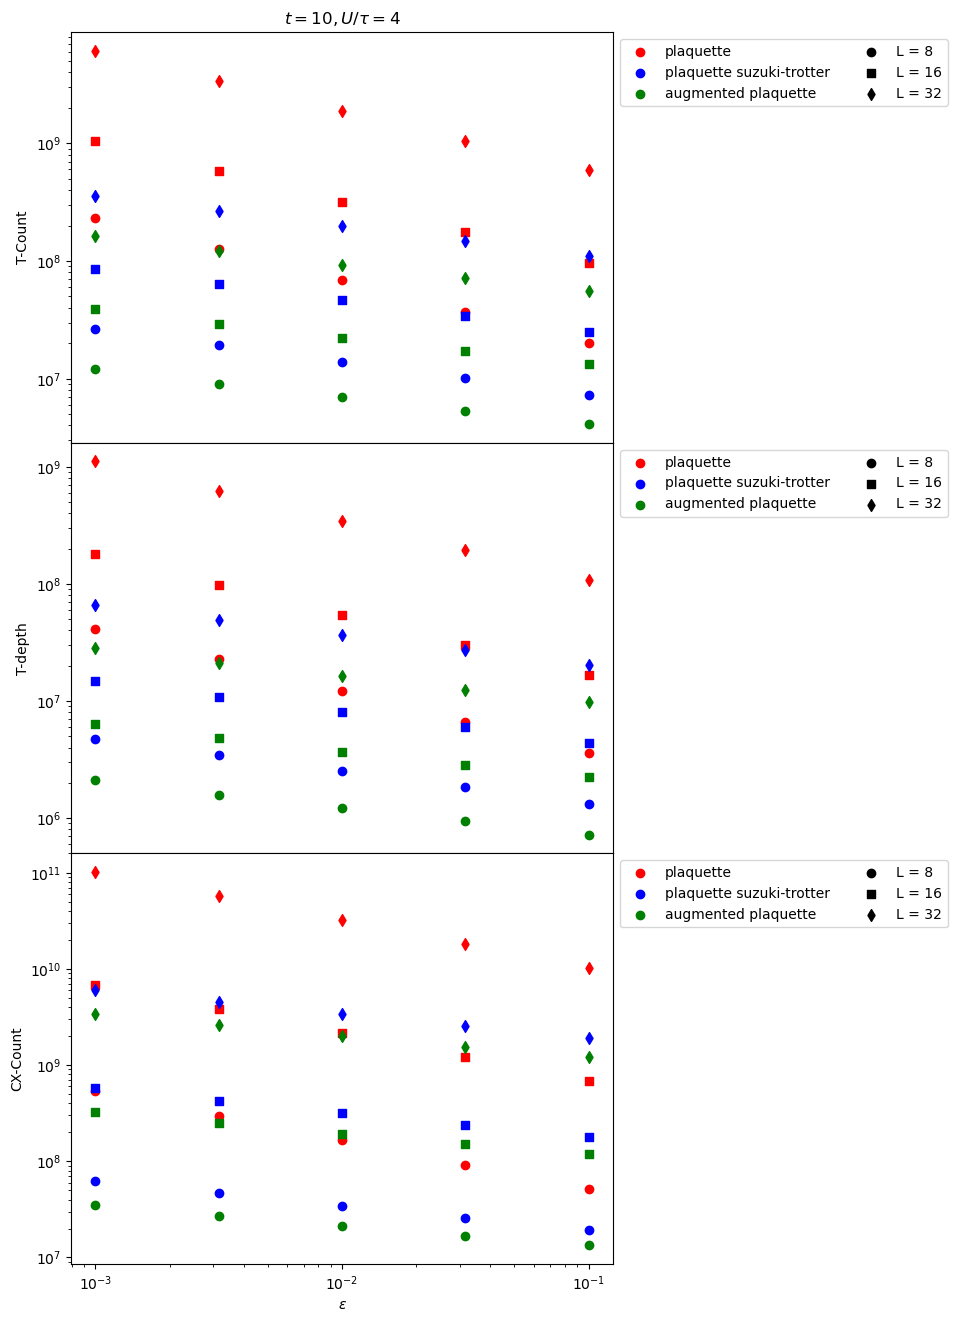

In [3]:
t = 10
logeps_list = np.linspace(-3, -1, 5)
eps_list = np.pow(10, logeps_list)
Ls = [8, 16, 32]

colors = ['r', 'b', 'g']
marker_styles = ['o', 's', 'd']
comp_strats = ["plaquette", "plaquette suzuki-trotter", "augmented plaquette"]

fig, (ax_t, ax_td, ax_cx) = plt.subplots(3,1, figsize = figsz, sharex = True)
fig.subplots_adjust(wspace=0, hspace=0)
ax_t.set_title(rf"$t = {t}, U / \tau = {U}$")
ax_cx.set_xlabel(rf"$\varepsilon$")

for ax, g in zip([ax_t, ax_td, ax_cx], ["T-Count", "T-depth", "CX-Count"]):
    for strat, color in zip(comp_strats, colors):
        ax.scatter([],[], c = color, marker = "o", label = strat)
    for L, marker in zip(Ls, marker_styles):
        ax.scatter([],[], c = "k", marker = marker, label = f"L = {L}")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend(ncol = 2, loc = "upper left", bbox_to_anchor = (1.0,1.0))
    ax.set_ylabel(f"{g}")

for gate_gen, color, comp_strat in zip([gates_2nd_order, gates_4th_order, gates_augmented], colors, comp_strats):
    for L, marker_style in zip(Ls, marker_styles):
        t_gates, u_gates = gate_gen(L)
        dcts = [hamiltonian_simulation_cost(
            t, 
            e, 
            t_gates, 
            outer_gates=u_gates, 
            **compute_number_of_trotter_steps_kwargs(t, e * (1-x), U, tau, L, comp_strat),
            x=x,
            synthesize_rotation_with="RUS"
        )
            for e in eps_list
               ]
        ys_t = [dict_to_t_count(d) for d in dcts]
        ys_td = [dict_to_t_depth(d) for d in dcts]
        ys_cx = [dict_to_cx_count(d) for d in dcts]
        ax_t.scatter(eps_list, ys_t, marker = marker_style, c = color)
        ax_td.scatter(eps_list, ys_td, marker = marker_style, c = color)
        ax_cx.scatter(eps_list, ys_cx, marker = marker_style, c = color)

plaquette
t count: [2004708, 4380288, 9707704, 21200708, 46306288, 101121388, 223720900, 488299488, 1065611068, 2325097016]
t depth: [359415, 784485, 1735173, 3785875, 8261497, 18025035, 39810631, 86820525, 189316043, 412753601]
cx count: [5103624, 11054964, 23950656, 51877164, 112396920, 242146104, 524619540, 1136558064, 2462240652, 5334045000]
t count: [9679452, 21007132, 45625356, 99065004, 216795692, 470688636, 1021876380, 2235230988, 4851929212, 10531311100]
t depth: [1676927, 3631125, 7868919, 17048301, 37150073, 80488795, 174383433, 379905209, 823014291, 1782898345]
cx count: [67553596, 145611516, 314109420, 677425548, 1461153660, 3151520716, 6797522220, 14661592524, 31623688252, 68209282108]
t count: [58791296, 127048692, 275537452, 595557840, 1287274260, 2791453596, 6033535136, 13040947380, 28186529736, 61116769008]
t depth: [10877349, 23469635, 50745531, 109518337, 236365671, 511041531, 1102957357, 2380457547, 5137603229, 11107699785]
cx count: [1011523896, 2179146188, 469588

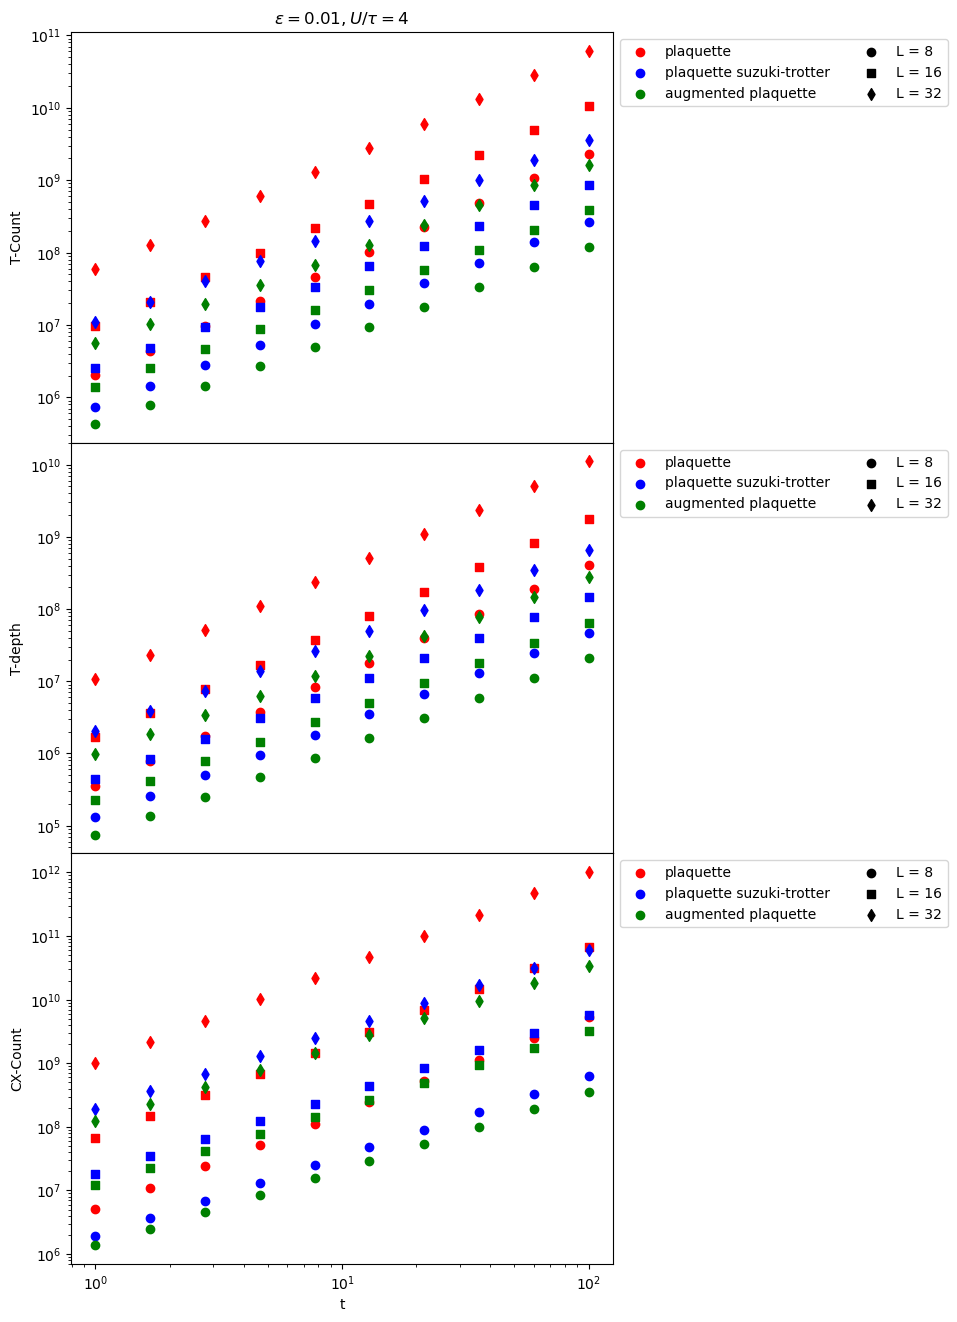

In [4]:
logts = np.linspace(0, 2, 10)
ts = np.pow(10, logts)
eps = 0.01
Ls = [8, 16, 32]

colors = ['r', 'b', 'g']
marker_styles = ['o', 's', 'd']
comp_strats = ["plaquette", "plaquette suzuki-trotter", "augmented plaquette"]

fig, (ax_t, ax_td, ax_cx) = plt.subplots(3,1, figsize = figsz, sharex = True)
fig.subplots_adjust(wspace=0, hspace=0)
ax_t.set_title(rf"$\varepsilon = {eps}, U / \tau = {U}$")
ax_cx.set_xlabel(rf"t")

for ax, g in zip([ax_t, ax_td, ax_cx], ["T-Count", "T-depth", "CX-Count"]):
    for strat, color in zip(comp_strats, colors):
        ax.scatter([],[], c = color, marker = "o", label = strat)
    for L, marker in zip(Ls, marker_styles):
        ax.scatter([],[], c = "k", marker = marker, label = f"L = {L}")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend(ncol = 2, loc = "upper left", bbox_to_anchor = (1.0,1.0))
    ax.set_ylabel(f"{g}")

for gate_gen, color, comp_strat in zip([gates_2nd_order, gates_4th_order, gates_augmented], colors, comp_strats):
    print(comp_strat)
    for L, marker_style in zip(Ls, marker_styles):
        t_gates, u_gates = gate_gen(L)
        dcts = [hamiltonian_simulation_cost(
            t, 
            eps, 
            t_gates, 
            outer_gates=u_gates, 
            **compute_number_of_trotter_steps_kwargs(t, eps * (1-x), U, tau, L, comp_strat),
            x=x,
            synthesize_rotation_with="RUS"
        )
            for t in ts
               ]
        ys_t = [dict_to_t_count(d) for d in dcts]
        ys_td = [dict_to_t_depth(d) for d in dcts]
        ys_cx = [dict_to_cx_count(d) for d in dcts]
        print("t count:", ys_t)
        print("t depth:", ys_td)
        print("cx count:", ys_cx)
        ax_t.scatter(ts, ys_t, marker = marker_style, c = color)
        ax_td.scatter(ts, ys_td, marker = marker_style, c = color)
        ax_cx.scatter(ts, ys_cx, marker = marker_style, c = color)

# Quantum Phase Estimation

In [5]:
tau = 1
U = 4
x = 0.01

import math

def qubitization_t_count(eps: float, N: int) -> int:
    return math.ceil((20*np.sqrt(2) * np.pi* tau + 5*np.sqrt(2) * np.pi*U) * (2*N)**2 / eps)

def qubitization_t_depth(eps: float, N: int) -> int:
    return math.ceil(qubitization_t_count(eps, N) / 4)  
    
def get_evolution_time_and_count_func(type: str, s: int):
    def f(e):
        return compute_evolution_time_and_number_of_simulation_circuits_for_qpe(
            e,U,tau,s, type, unitary_decomp=False
        )
    return f


def get_trotter_count_func(type: str, s: int):
    def f(t,e):
        return compute_number_of_trotter_steps(
            t,e,U,tau,s, type, 
        )
    return f

def gates_2nd_order(L: int) -> tuple[dict, ...]:
    m = L**2//2
    return {
        HWPGate({FreeFermionicC4Tile():L**2 // 2}, m): 3,
        HWPGate({ShiftedOccupationPair():L**2}, 2*m): 1,
        Fswap(): 4*fswap_network_count(plaquette_decomposition_permutations(L)),
    }, {HWPGate({ShiftedOccupationPair():L**2}, 2*m): 1}

def gates_4th_order(L: int) -> tuple[dict, ...]:
    m = L**2//2
    return {
        HWPGate({FreeFermionicC4Tile():L**2 // 2}, m): 15,
        HWPGate({ShiftedOccupationPair():L**2}, 2*m): 5,
        Fswap(): 5*4*fswap_network_count(plaquette_decomposition_permutations(L)),
    }, {HWPGate({ShiftedOccupationPair():L**2}, 2*m): 1}

def gates_augmented(L: int) -> tuple[dict, ...]:
    m = L**2//2
    aug_counts = {x: fswap_network_count(y) for x,y in augmented_permutations(L).items()}
    fswap_count = 2*(4*fswap_network_count(plaquette_decomposition_permutations(L))
                +2*aug_counts["red_to_augred"] + 2*aug_counts["augred_to_augblue"]
                +2*aug_counts["red_reflection"]
        )
    return {
       HWPGate({FreeFermionicC4Tile():L**2 // 2}, m): 6,
         HWPGate({ShiftedOccupationPair():L**2}, 2*m): 2,
        HWPGate({SpinSymmetricMixedControlledHappa(): L**2 // 2}, m): 4,
        Fswap(): fswap_count
    }, {HWPGate({FreeFermionicC4Tile():L**2 // 2}, m): 6, HWPGate({SpinSymmetricMixedControlledKappa(): L**2//2}, m): 8}

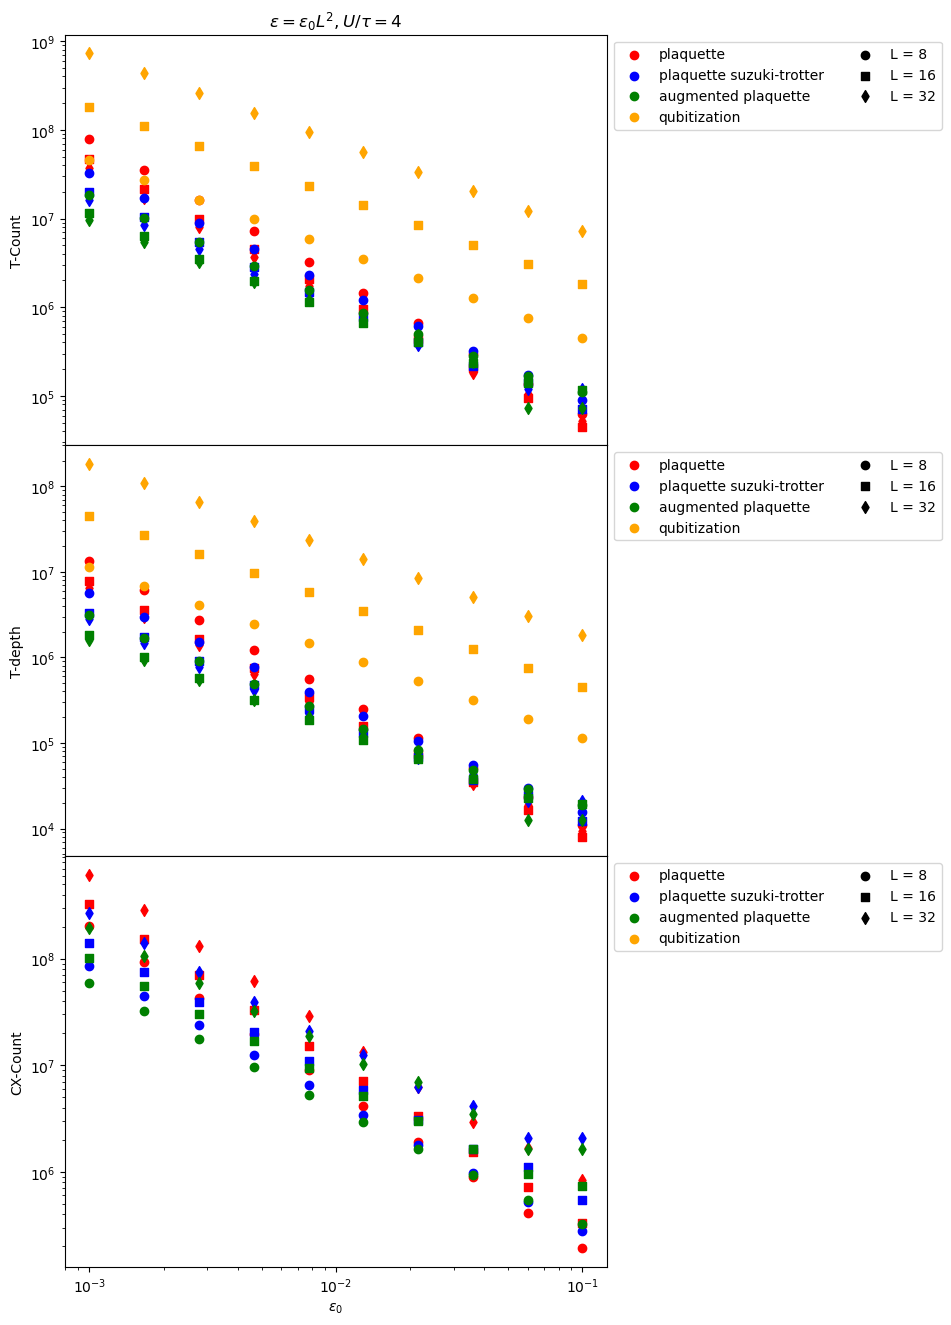

In [6]:
logeps_list = np.linspace(-3, -1, 10)
eps_list = np.pow(10, logeps_list)
Ls = [8, 16, 32]

colors = ['r', 'b', 'g', "orange"]
marker_styles = ['o', 's', 'd']
comp_strats = ["plaquette", "plaquette suzuki-trotter", "augmented plaquette", "qubitization"]

fig, (ax_t, ax_td, ax_cx) = plt.subplots(3,1, figsize = figsz, sharex = True)
fig.subplots_adjust(wspace=0, hspace=0)
ax_t.set_title(rf"$\varepsilon = \varepsilon_0 L^2, U / \tau = {U}$")
ax_cx.set_xlabel(rf"$\varepsilon_0$")

for ax, g in zip([ax_t, ax_td, ax_cx], ["T-Count", "T-depth", "CX-Count"]):
    for strat, color in zip(comp_strats, colors):
        ax.scatter([],[], c = color, marker = "o", label = strat)
    for L, marker in zip(Ls, marker_styles):
        ax.scatter([],[], c = "k", marker = marker, label = f"L = {L}")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend(ncol = 2, loc = "upper left", bbox_to_anchor = (1.0,1.0))
    ax.set_ylabel(f"{g}")

for gate_gen, color, comp_strat in zip([gates_2nd_order, gates_4th_order, gates_augmented, _], colors, comp_strats):
    for L, marker_style in zip(Ls, marker_styles):
        if comp_strat == "qubitization":
            ys_t = [qubitization_t_count(e * L**2, L**2) for e in eps_list]
            ys_td = [qubitization_t_depth(e * L**2, L**2) for e in eps_list]
            ax_t.scatter(eps_list, ys_t, marker = marker_style, c = color)
            ax_td.scatter(eps_list, ys_td, marker = marker_style, c = color)
        else:
            t_gates, u_gates = gate_gen(L)
            dcts = [adaptive_phase_estimation_resources(
                e * L**2, 
                t_gates, 
                unitary_gates=u_gates, 
                **compute_evolution_time_and_number_of_simulation_circuits_for_qpe_kwargs(e * L**2 * (1-x),  U, tau, L, comp_strat, unitary_decomp=False),
                x=x,
                synthesize_rotation_with="RUS"
            )
                for e in eps_list
                   ]
            ys_t = [dict_to_t_count(d) for d in dcts]
            ys_td = [dict_to_t_depth(d) for d in dcts]
            ys_cx = [dict_to_cx_count(d) for d in dcts]
            ax_t.scatter(eps_list, ys_t, marker = marker_style, c = color)
            ax_td.scatter(eps_list, ys_td, marker = marker_style, c = color)
            ax_cx.scatter(eps_list, ys_cx, marker = marker_style, c = color)

plaquette
t count: [39217360, 97136604, 197968851, 343280520, 563907584, 854369840, 1247522544]
t depth: [6703790, 15990327, 32330371, 57835115, 94955040, 146308345, 213667800]
cx count: [102127184, 451078092, 1349703971, 3192611320, 6505686784, 11900834048, 20134369392]
t count: [115327214, 282421824, 567709446, 985524396, 1614605100, 2439414726, 3557549501]
t depth: [19677685, 46300912, 92395101, 165368034, 270711843, 416313825, 607187942]
cx count: [293266270, 1280959168, 3825316902, 9039776841, 18413907234, 33683470812, 56967754440]
t count: [1404426307, 3329526630, 6652148586, 11345143128, 18565400634, 27786860058, 40534102532]
t depth: [238725903, 541723060, 1070435661, 1888946480, 3082759625, 4710594993, 6863319510]
cx count: [3360889325, 14464611930, 42985546140, 101338915744, 206238796516, 377017687494, 637457332001]
plaquette suzuki-trotter
t count: [18634356, 37483008, 66487557, 103496163, 155496750, 217768424, 298714312]
t depth: [3187441, 6188091, 10896569, 17485453, 26260

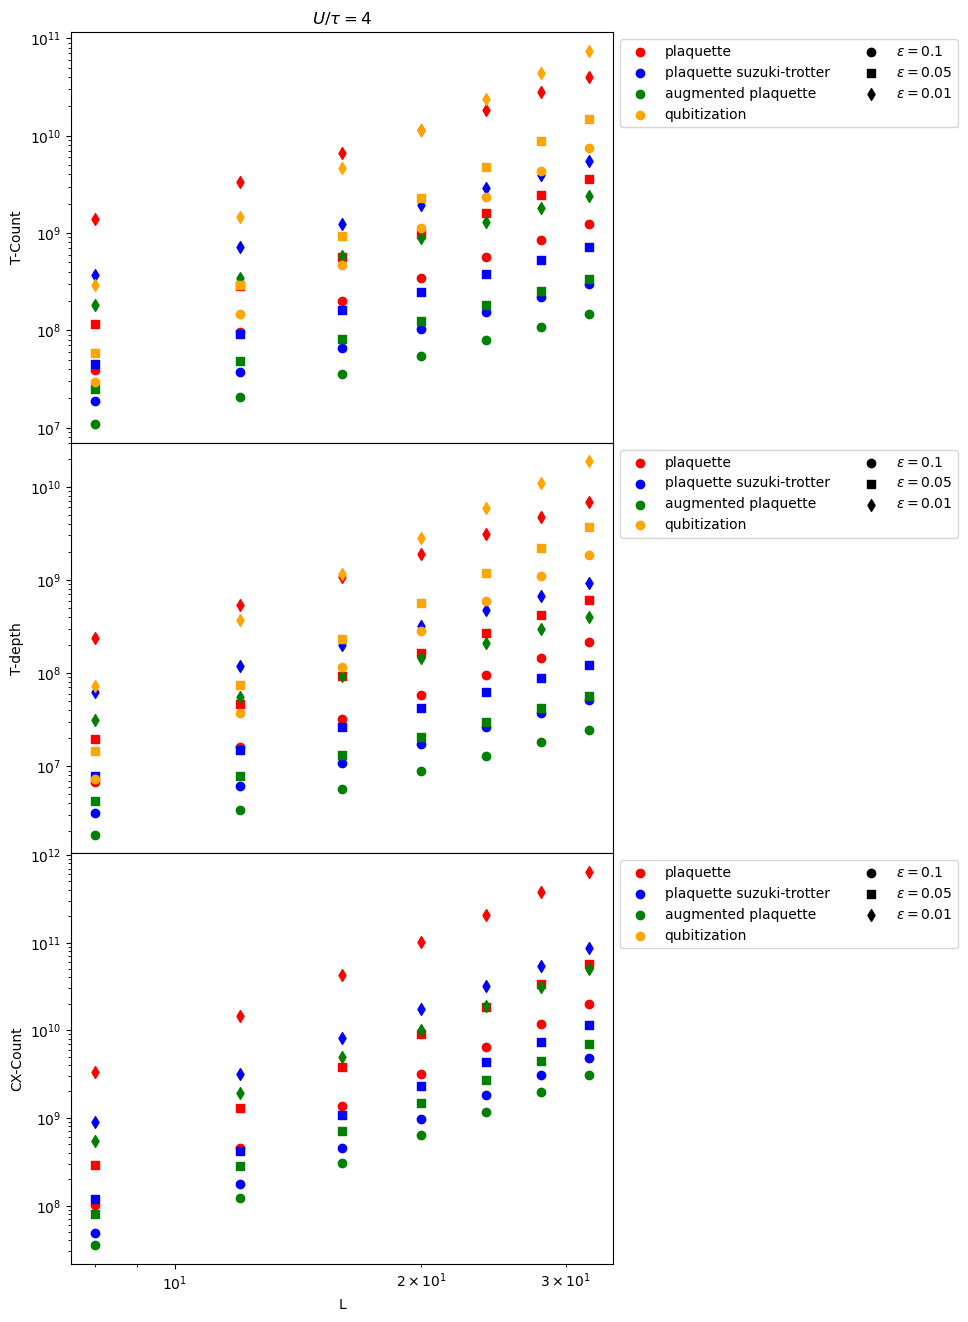

In [7]:
Ls = [8, 12, 16, 20, 24, 28, 32]
epss = [0.1, 0.05, 0.01]

colors = ['r', 'b', 'g', "orange"]
marker_styles = ['o', 's', 'd']
comp_strats = ["plaquette", "plaquette suzuki-trotter", "augmented plaquette", "qubitization"]

fig, (ax_t, ax_td, ax_cx) = plt.subplots(3,1, figsize = figsz, sharex = True)
fig.subplots_adjust(wspace=0, hspace=0)
ax_t.set_title(rf"$U / \tau = {U}$")
ax_cx.set_xlabel(rf"L")

for ax, g in zip([ax_t, ax_td, ax_cx], ["T-Count", "T-depth", "CX-Count"]):
    for strat, color in zip(comp_strats, colors):
        ax.scatter([],[], c = color, marker = "o", label = strat)
    for e, marker in zip(epss, marker_styles):
        ax.scatter([],[], c = "k", marker = marker, label = rf"$\varepsilon = {e}$")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend(ncol = 2, loc = "upper left", bbox_to_anchor = (1.0,1.0))
    ax.set_ylabel(f"{g}")

for gate_gen, color, comp_strat in zip([gates_2nd_order, gates_4th_order, gates_augmented, "_"], colors, comp_strats):
    print(comp_strat)
    for e, marker_style in zip(epss, marker_styles):
        if comp_strat == "qubitization":
            ys_t = [qubitization_t_count(e , L**2) for L in Ls]
            ys_td = [qubitization_t_depth(e , L**2) for L in Ls]
            ax_t.scatter(Ls, ys_t, marker = marker_style, c = color)
            ax_td.scatter(Ls, ys_td, marker = marker_style, c = color)
        else:
            ys_t, ys_td, ys_cx = [], [], []
            for L in Ls:
                t_gates, u_gates = gate_gen(L)
                dct = adaptive_phase_estimation_resources(
                    e, 
                    t_gates, 
                    unitary_gates=u_gates, 
                    **compute_evolution_time_and_number_of_simulation_circuits_for_qpe_kwargs(e * (1-x),  U, tau, L, comp_strat, unitary_decomp=False),
                    x=x,
                    synthesize_rotation_with="RUS"
                )
                ys_t.append(dict_to_t_count(dct))
                ys_td.append(dict_to_t_depth(dct))
                ys_cx.append(dict_to_cx_count(dct))
            ax_t.scatter(Ls, ys_t, marker = marker_style, c = color)
            ax_td.scatter(Ls, ys_td, marker = marker_style, c = color)
            ax_cx.scatter(Ls, ys_cx, marker = marker_style, c = color)
        print("t count:", ys_t)
        print("t depth:", ys_td)
        print("cx count:", ys_cx)
        